In [1]:
# Install NLTK
!pip install nltk

# Import everything we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk

# Download VADER — this is the sentiment analysis tool inside NLTK
nltk.download('vader_lexicon')

# Import VADER
from nltk.sentiment.vader import SentimentIntensityAnalyzer

print("All done! ✅")

All done! ✅


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Generate Feedback Data

In [2]:
np.random.seed(42)

positive_comments = [
    "The mentorship was absolutely amazing and helpful",
    "I learned so much during this internship",
    "Great experience, very supportive team",
    "My mentor guided me really well throughout",
    "Loved the tasks, very practical and engaging",
    "The team was friendly and welcoming",
    "Best internship experience I have ever had",
    "Very organized program with clear goals",
    "I grew a lot professionally during this program",
    "Excellent opportunity to learn real world skills",
]

neutral_comments = [
    "The experience was okay, nothing special",
    "Tasks were average, could be more challenging",
    "It was a decent internship overall",
    "Some days were productive, some were not",
    "The program was fine but nothing stood out",
    "Mentor meetings were regular but basic",
    "Work was manageable but not very exciting",
    "It was an average learning experience",
    "The internship met my basic expectations",
    "Nothing extraordinary but not bad either",
]

negative_comments = [
    "The tasks were too repetitive and boring",
    "Mentor was rarely available for guidance",
    "I felt lost most of the time with no direction",
    "Very poor communication from the team",
    "The workload was overwhelming and unmanageable",
    "Did not learn anything useful during this program",
    "Expectations were unclear from the beginning",
    "The internship was very disorganized",
    "No proper feedback was given on my work",
    "Felt ignored and unsupported throughout",
]

# Mix them
all_comments = (positive_comments * 7 + neutral_comments * 7 + negative_comments * 6)
np.random.shuffle(all_comments)
all_comments = all_comments[:200]

df = pd.DataFrame({
    'Intern_ID' : [f'INT{str(i).zfill(3)}' for i in range(1, 201)],
    'Department': np.random.choice(['Engineering', 'Data Science', 'Design',
                                    'Marketing', 'HR'], 200),
    'Month'     : np.random.choice(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'], 200),
    'Feedback'  : all_comments
})

print(f"Data created! {df.shape}")
print(df.head())

Data created! (200, 4)
  Intern_ID    Department Month  \
0    INT001        Design   Feb   
1    INT002  Data Science   Jun   
2    INT003            HR   Jun   
3    INT004     Marketing   Jan   
4    INT005  Data Science   May   

                                            Feedback  
0             Mentor meetings were regular but basic  
1                The team was friendly and welcoming  
2  The mentorship was absolutely amazing and helpful  
3            No proper feedback was given on my work  
4           The internship met my basic expectations  


Run Sentiment Analysis

In [3]:
# Create the analyser
sia = SentimentIntensityAnalyzer()

# get a compound score between -1  and +1
df['Compound_Score'] = df['Feedback'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Classify based on the score
def classify(score):
    if score >= 0.05:   return 'Positive'
    elif score <= -0.05: return 'Negative'
    else:                return 'Neutral'

df['Sentiment'] = df['Compound_Score'].apply(classify)

print(df[['Feedback', 'Compound_Score', 'Sentiment']].head(10))
print("\nSentiment counts:")
print(df['Sentiment'].value_counts())

                                            Feedback  Compound_Score Sentiment
0             Mentor meetings were regular but basic          0.0000   Neutral
1                The team was friendly and welcoming          0.7269  Positive
2  The mentorship was absolutely amazing and helpful          0.7996  Positive
3            No proper feedback was given on my work         -0.2960  Negative
4           The internship met my basic expectations          0.0000   Neutral
5             Mentor meetings were regular but basic          0.0000   Neutral
6   Excellent opportunity to learn real world skills          0.7579  Positive
7           The tasks were too repetitive and boring         -0.5106  Negative
8     The workload was overwhelming and unmanageable          0.0000   Neutral
9                The team was friendly and welcoming          0.7269  Positive

Sentiment counts:
Sentiment
Positive    77
Negative    62
Neutral     61
Name: count, dtype: int64


Summary

In [5]:
total    = len(df)
positive = len(df[df['Sentiment'] == 'Positive'])
neutral  = len(df[df['Sentiment'] == 'Neutral'])
negative = len(df[df['Sentiment'] == 'Negative'])

print(" SENTIMENT SUMMARY ")
print(f"Total Feedback   : {total}")
print(f"Positive         : {positive} ({round(positive/total*100, 1)}%)")
print(f"Neutral          : {neutral}  ({round(neutral/total*100, 1)}%)")
print(f"Negative         : {negative} ({round(negative/total*100, 1)}%)")
print(f"\nAvg Compound Score : {df['Compound_Score'].mean():.3f}")

 SENTIMENT SUMMARY 
Total Feedback   : 200
Positive         : 77 (38.5%)
Neutral          : 61  (30.5%)
Negative         : 62 (31.0%)

Avg Compound Score : 0.086


Draw the Dashboard

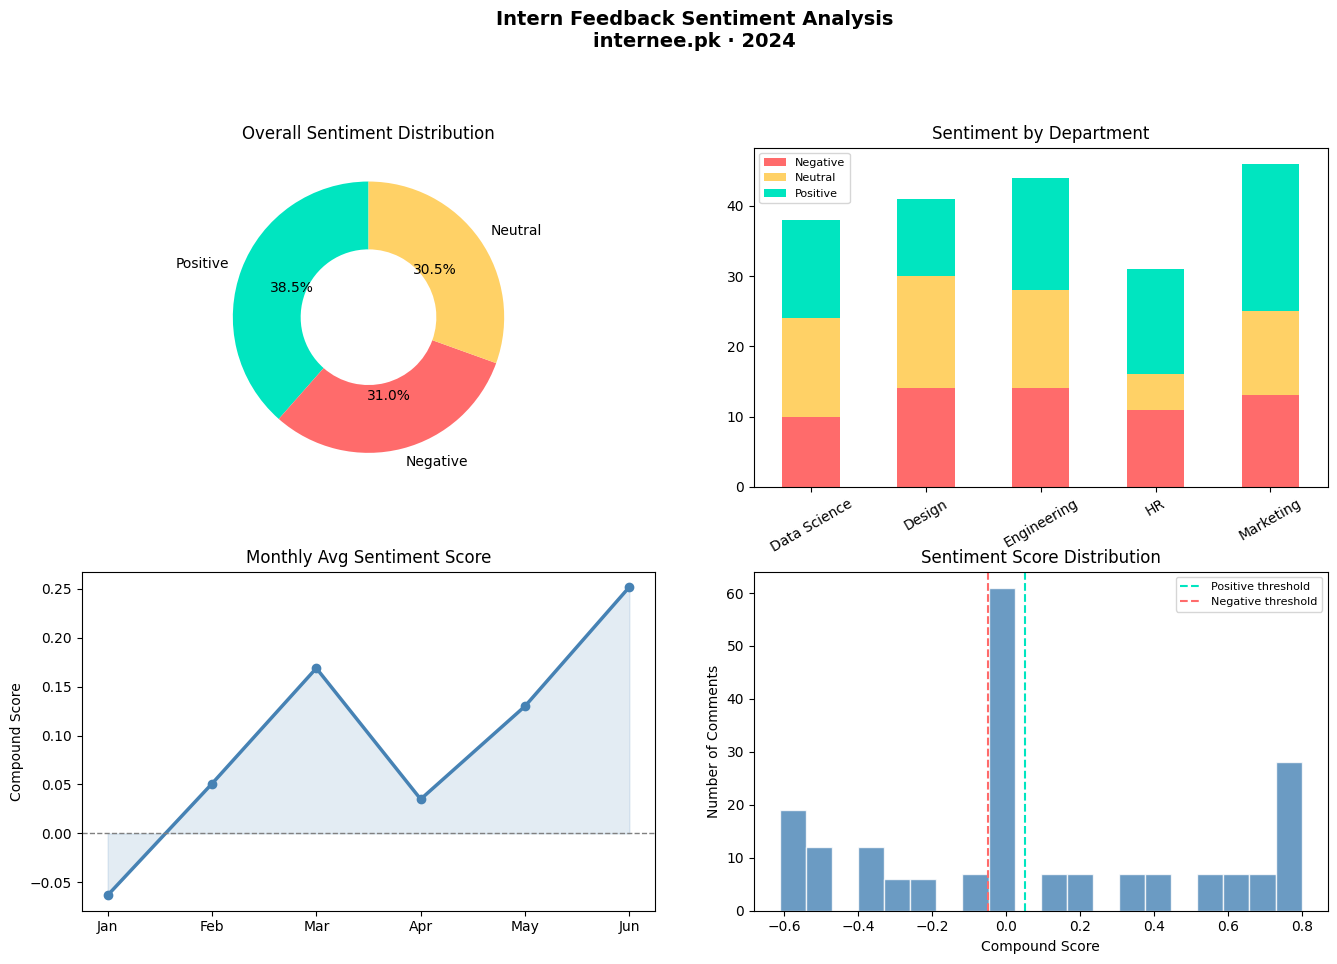

✅ Dashboard saved!


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Intern Feedback Sentiment Analysis\ninternee.pk · 2024',
             fontsize=14, fontweight='bold')
fig.tight_layout(pad=4)

COLORS = {'Positive': '#00e5c0', 'Neutral': '#ffd166', 'Negative': '#ff6b6b'}

# Chart 1 — Sentiment Distribution (Pie)
sentiment_counts = df['Sentiment'].value_counts()
axes[0,0].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    colors=[COLORS[s] for s in sentiment_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.5)
)
axes[0,0].set_title('Overall Sentiment Distribution')

# Chart 2 — Sentiment by Department (Stacked Bar)
dept_sent = df.groupby(['Department', 'Sentiment']).size().unstack(fill_value=0)
dept_sent.plot(
    kind='bar', ax=axes[0,1], stacked=True,
    color=[COLORS.get(c, 'grey') for c in dept_sent.columns],
    edgecolor='none'
)
axes[0,1].set_title('Sentiment by Department')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].legend(fontsize=8)

# Chart 3 — Monthly Sentiment Trend (Line)
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
monthly_avg = df.groupby('Month')['Compound_Score'].mean().reindex(month_order)
axes[1,0].plot(monthly_avg.index, monthly_avg.values,
               marker='o', color='steelblue', linewidth=2.5)
axes[1,0].fill_between(monthly_avg.index, monthly_avg.values, alpha=0.15, color='steelblue')
axes[1,0].axhline(0, color='grey', linewidth=1, linestyle='--')
axes[1,0].set_title('Monthly Avg Sentiment Score')
axes[1,0].set_ylabel('Compound Score')

# Chart 4 — Sentiment Score Distribution (Histogram)
colors_hist = df['Sentiment'].map(COLORS)
axes[1,1].hist(df['Compound_Score'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[1,1].axvline(0.05,  color='#00e5c0', linewidth=1.5, linestyle='--', label='Positive threshold')
axes[1,1].axvline(-0.05, color='#ff6b6b', linewidth=1.5, linestyle='--', label='Negative threshold')
axes[1,1].set_title('Sentiment Score Distribution')
axes[1,1].set_xlabel('Compound Score')
axes[1,1].set_ylabel('Number of Comments')
axes[1,1].legend(fontsize=8)

plt.savefig('sentiment_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved!")